In [1]:
from functools import lru_cache
import glob
import matplotlib.pyplot as plt
import mplhep
import numpy as np
import os
import pandas as pd
import ROOT
import seaborn as sns
import yaml
from IPython.display import display

sns.set_style("white")
sns.set_context("notebook")
sns.set_palette("colorblind")

ROOT.TH1.AddDirectory(False)

try:
    ROOT.EnableImplicitMT(8)
except AttributeError:
    pass

# -----------------------------------------------------------------------------
# Notebook configuration
# -----------------------------------------------------------------------------

# Shapes tag
SHAPES_TAG = "shapes-2026-05-07"

# Safety: limit rows when experimenting to avoid huge memory usage (None = no limit)
MAX_ROWS_PER_FILE = None

# Base path to the validation database
VALIDATION_DB_DIR = os.path.join("/work/mmolch/xyh-bbtautau-crown/bbtautau/validation_database", SHAPES_TAG)

# The name of the weight to be inspected
WEIGHT_BRANCH = "id_wgt_bjet"

# Number of bins to use in histograms
HIST_BINS = 80

# Default name of the ntuple tree in ROOT files
TREE_NAME = "ntuple"

In [2]:
def sample_name_from_yaml(yaml_path: str) -> str:
    parts = os.path.splitext(os.path.basename(yaml_path))[0].split("_")
    if len(parts) > 2 and parts[0].isdigit():
        return "_".join(parts[2:])
    return os.path.basename(yaml_path)

def load_sample_file_map(validation_db_dir: str) -> dict[str, dict[str, object]]:
    sample_file_map = {}
    for yaml_path in sorted(glob.glob(os.path.join(validation_db_dir, "*.yaml"))):
        with open(yaml_path, "r", encoding="utf-8") as handle:
            yaml_data = yaml.safe_load(handle) or {}
        root_files = list((yaml_data.get("files") or {}).keys())
        sample_name = sample_name_from_yaml(yaml_path)
        sample_file_map[sample_name] = {
            "yaml_path": yaml_path,
            "root_files": root_files,
        }
    return sample_file_map

@lru_cache(maxsize=None)
def file_has_weight_branch(file_path: str) -> bool:
    root_file = ROOT.TFile.Open(file_path)
    if not root_file or root_file.IsZombie():
        return False
    try:
        tree = root_file.Get(TREE_NAME)
        return tree is not None and tree.GetBranch(WEIGHT_BRANCH) is not None
    finally:
        root_file.Close()

def load_weight_values(file_paths: list[str]) -> tuple[np.ndarray | None, list[str], dict[str, int]]:
    usable_files = [file_path for file_path in file_paths if file_has_weight_branch(file_path)]
    if not usable_files:
        return None, [], {"total_raw": 0, "total_nonfinite": 0, "total_finite": 0}

    value_chunks = []
    selected_files = []
    total_raw = 0
    total_nonfinite = 0
    
    for file_path in usable_files:
        try:
            rdf = ROOT.RDataFrame(TREE_NAME, [file_path])
            arrays = rdf.AsNumpy([WEIGHT_BRANCH])
            values = np.asarray(arrays[WEIGHT_BRANCH], dtype=np.float64)
        except Exception as exc:
            print(f"Skipping {file_path}: {exc}")
            continue

        total_raw += values.size
        finite_values = values[np.isfinite(values)]
        nonfinite_count = values.size - finite_values.size
        total_nonfinite += nonfinite_count
        
        if nonfinite_count > 0:
            pct = 100.0 * nonfinite_count / values.size
            print(f"  {file_path}: {nonfinite_count}/{values.size} ({pct:.2f}%) non-finite values filtered")
        
        if finite_values.size == 0:
            continue

        value_chunks.append(finite_values)
        selected_files.append(file_path)

    if not value_chunks:
        return None, [], {"total_raw": total_raw, "total_nonfinite": total_nonfinite, "total_finite": 0}

    concatenated = np.concatenate(value_chunks) if len(value_chunks) > 1 else value_chunks[0]
    total_finite = concatenated.size
    
    stats = {
        "total_raw": total_raw,
        "total_nonfinite": total_nonfinite,
        "total_finite": total_finite,
    }
    
    if total_nonfinite > 0:
        pct = 100.0 * total_nonfinite / total_raw
        print(f"  ⚠️  Total: {total_nonfinite}/{total_raw} ({pct:.2f}%) non-finite weights")
    
    return concatenated, selected_files, stats

def weight_summary(values: np.ndarray) -> dict[str, float]:
    if values.size == 0:
        return {
            "events": 0,
            "min": np.nan,
            "q05": np.nan,
            "median": np.nan,
            "mean": np.nan,
            "std": np.nan,
            "q95": np.nan,
            "max": np.nan,
        }

    q05, median, q95 = np.percentile(values, [5, 50, 95])
    return {
        "events": int(values.size),
        "min": float(np.min(values)),
        "q05": float(q05),
        "median": float(median),
        "mean": float(np.mean(values)),
        "std": float(np.std(values, ddof=0)),
        "q95": float(q95),
        "max": float(np.max(values)),
    }

def histogram_range(values: np.ndarray) -> tuple[float, float]:
    low = float(np.min(values))
    high = float(np.max(values))
    if low == high:
        spread = abs(low) * 0.1 or 1.0
        low -= spread
        high += spread
    return low, high

def plot_weight_distribution(sample_name: str, values: np.ndarray, ax=None):
    if ax is None:
        _, ax = plt.subplots()

    low, high = histogram_range(values)
    h = np.histogram(values, bins=HIST_BINS, range=(low, high))
    mplhep.histplot(h, ax=ax)
    ax.set_xlabel(WEIGHT_BRANCH)
    ax.set_ylabel("Events")
    ax.set_title(sample_name)
    ax.grid(True, alpha=0.3)
    return ax


In [3]:
sample_file_map = load_sample_file_map(VALIDATION_DB_DIR)
sample_names = sorted(sample_file_map)

print(f"Loaded {len(sample_names)} samples from {VALIDATION_DB_DIR}")
for sample_name in sample_names:
    sample_info = sample_file_map[sample_name]
    print(f"  {sample_name}: {len(sample_info['root_files'])} ROOT files")

if not sample_names:
    raise RuntimeError(f"No validation database YAML files found in {VALIDATION_DB_DIR}")

Loaded 40 samples from /work/mmolch/xyh-bbtautau-crown/bbtautau/validation_database/shapes-2026-05-07
  dy_2e_m10to50: 70 ROOT files
  dy_2e_m50_0j: 55 ROOT files
  dy_2e_m50_1j: 211 ROOT files
  dy_2e_m50_2j: 32 ROOT files
  dy_2mu_m10to50: 102 ROOT files
  dy_2mu_m50_0j: 54 ROOT files
  dy_2mu_m50_1j: 33 ROOT files
  dy_2mu_m50_2j: 167 ROOT files
  dy_2tau_m10to50: 72 ROOT files
  dy_2tau_m50_0j: 267 ROOT files
  dy_2tau_m50_1j: 203 ROOT files
  dy_2tau_m50_2j: 160 ROOT files
  gluglu_h_2b: 23 ROOT files
  gluglu_h_2tau: 5 ROOT files
  muon: 452 ROOT files
  tb_2q_antitop_schannel: 10 ROOT files
  tb_2q_top_schannel: 9 ROOT files
  tb_lnu_antitop_schannel: 23 ROOT files
  tb_lnu_top_schannel: 28 ROOT files
  tbq_2q_antitop_tchannel: 83 ROOT files
  tbq_2q_top_tchannel: 78 ROOT files
  tbq_lnu_antitop_tchannel: 25 ROOT files
  tbq_lnu_top_tchannel: 40 ROOT files
  tt_2l2nu: 78 ROOT files
  tt_4q: 78 ROOT files
  tt_lnu2q: 79 ROOT files
  tth_h_2b: 3 ROOT files
  tth_h_non2b: 54 ROOT f


dy_2e_m10to50 (62/70 ROOT files with id_wgt_bjet, 152 events)
  min=0.290899, q05=0.530766, median=1, mean=1.00991, std=0.271521, q95=1.4361, max=2.93414


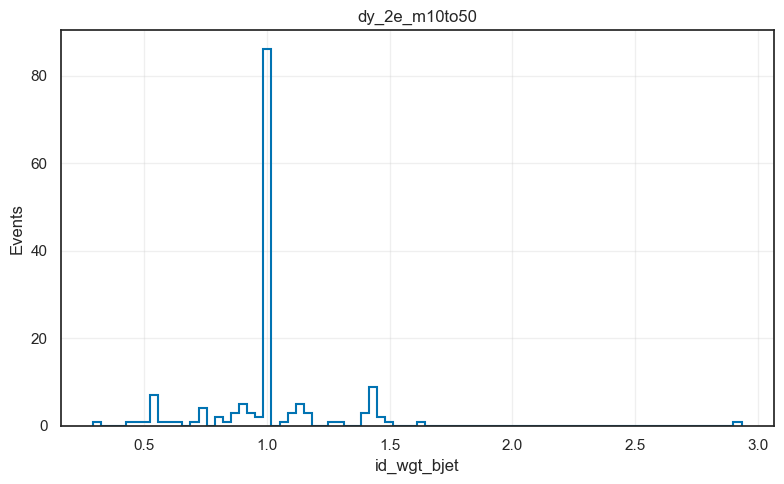


dy_2e_m50_0j (55/55 ROOT files with id_wgt_bjet, 462 events)
  min=0.229213, q05=0.530304, median=1, mean=1.00249, std=0.298933, q95=1.44264, max=2.09859


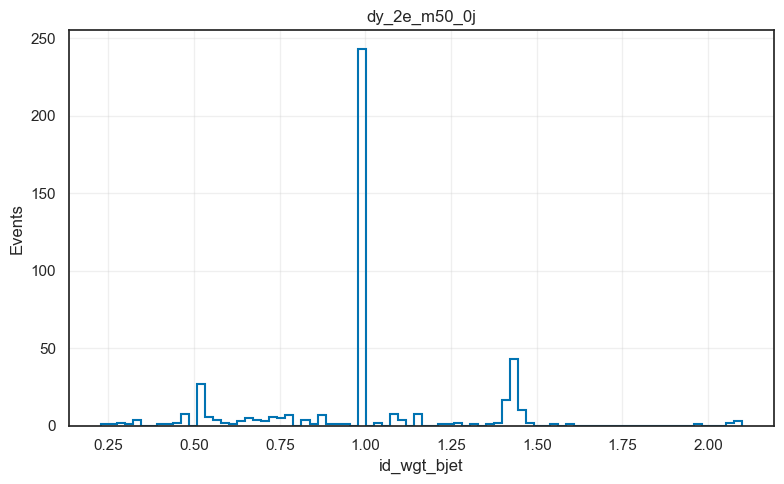


dy_2e_m50_1j (211/211 ROOT files with id_wgt_bjet, 4677 events)
  min=0.141443, q05=0.548552, median=1, mean=1.1107, std=0.309089, q95=1.48353, max=2.9979


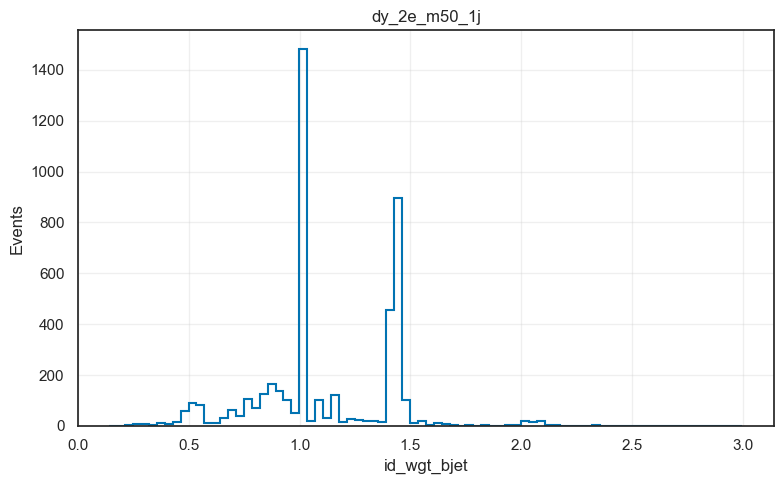


dy_2e_m50_2j (32/32 ROOT files with id_wgt_bjet, 14813 events)
  min=0.0550311, q05=0.440445, median=1, mean=1.05208, std=0.430151, q95=1.96781, max=5.86426


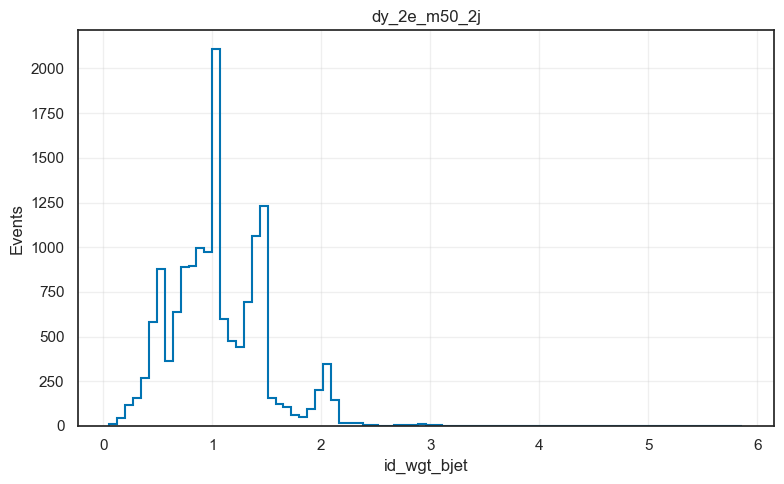


dy_2mu_m10to50 (102/102 ROOT files with id_wgt_bjet, 215725 events)
  min=0.0527285, q05=0.500793, median=1, mean=0.953642, std=0.248914, q95=1.4315, max=3.89489


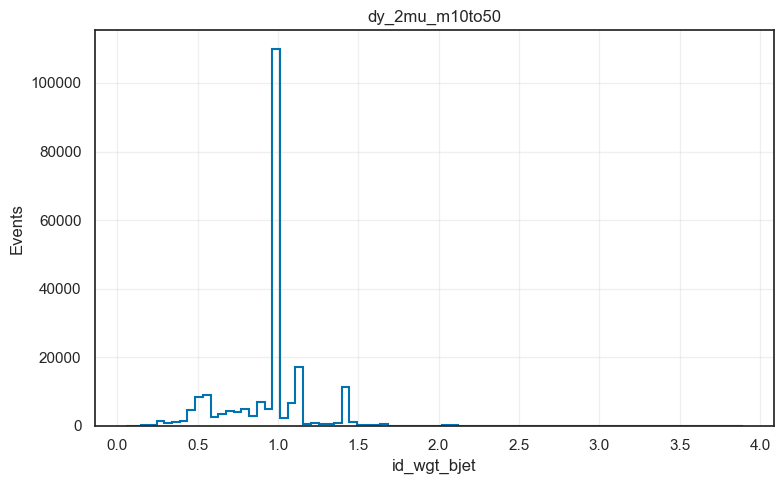


dy_2mu_m50_0j (54/54 ROOT files with id_wgt_bjet, 1174998 events)
  min=0.0406074, q05=0.570872, median=1, mean=1.08782, std=0.262507, q95=1.44378, max=6.03909


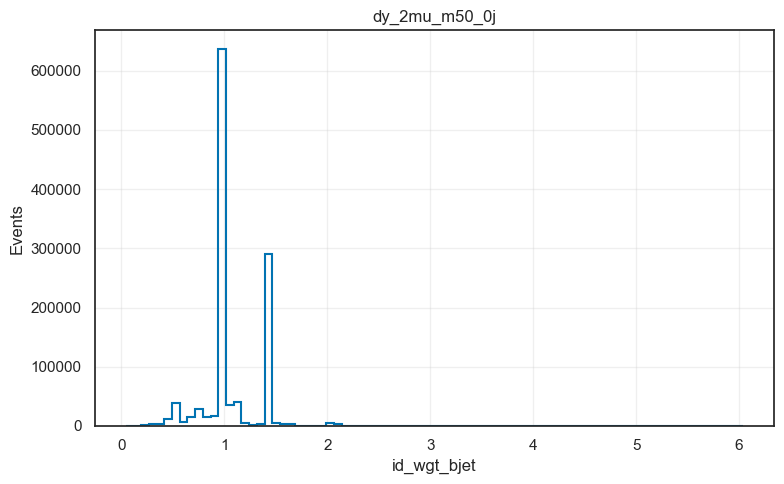


dy_2mu_m50_1j (33/33 ROOT files with id_wgt_bjet, 17025275 events)
  min=0.0231889, q05=0.615751, median=1, mean=1.11966, std=0.269942, q95=1.44865, max=7.30395


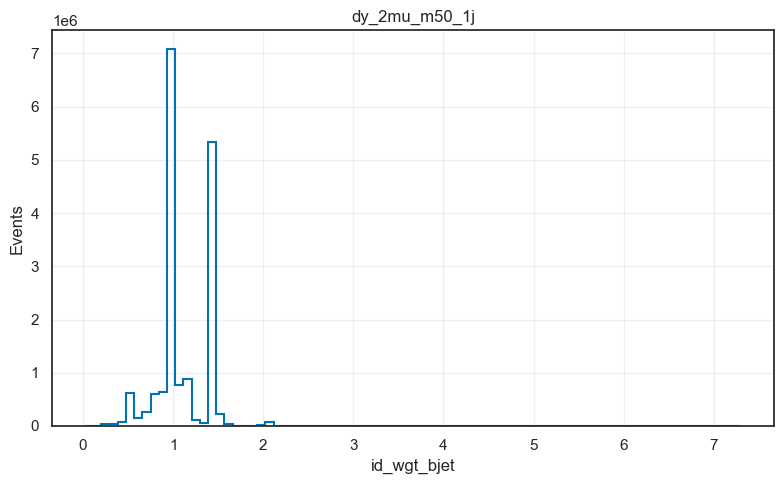


dy_2mu_m50_2j (167/167 ROOT files with id_wgt_bjet, 16613262 events)
  min=0.00806626, q05=0.424857, median=0.946682, mean=0.94884, std=0.370257, q95=1.44895, max=7.14868


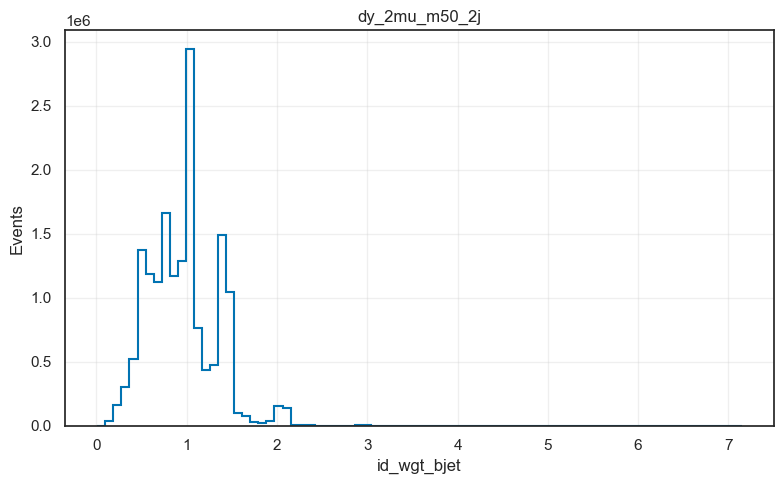


dy_2tau_m10to50 (72/72 ROOT files with id_wgt_bjet, 9261 events)
  min=0.0646694, q05=0.460957, median=1, mean=0.886643, std=0.24674, q95=1.21227, max=2.23572


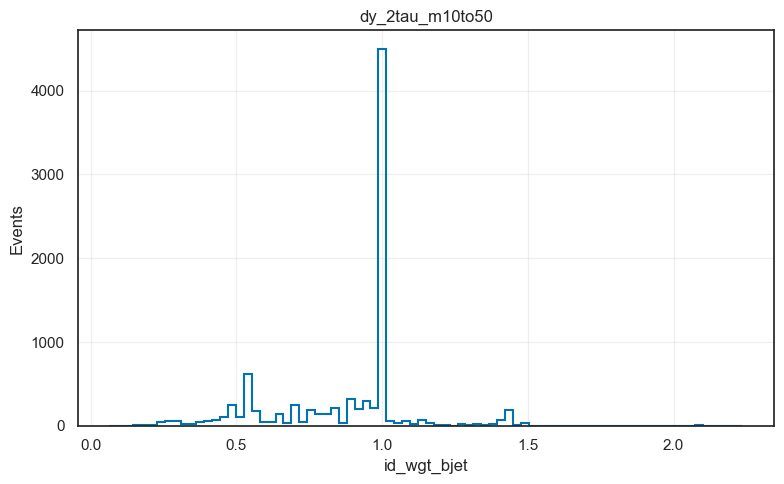


dy_2tau_m50_0j (267/267 ROOT files with id_wgt_bjet, 5084687 events)
  min=0.0336179, q05=0.817326, median=1, mean=0.98207, std=0.117374, q95=1, max=4.23291


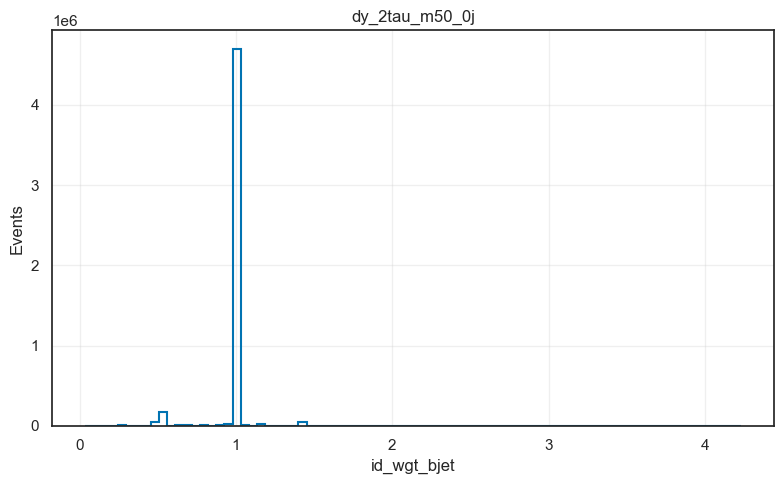


dy_2tau_m50_1j (203/203 ROOT files with id_wgt_bjet, 6995980 events)
  min=0.038476, q05=0.47835, median=0.944351, mean=0.858171, std=0.255352, q95=1.40561, max=4.93122


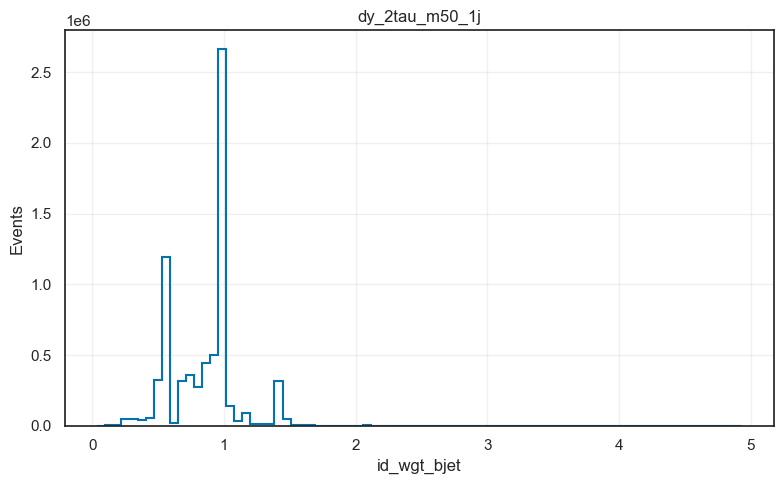


dy_2tau_m50_2j (160/160 ROOT files with id_wgt_bjet, 4820014 events)
  min=0.0137043, q05=0.293256, median=0.766105, mean=0.759206, std=0.31338, q95=1.37557, max=6.12563


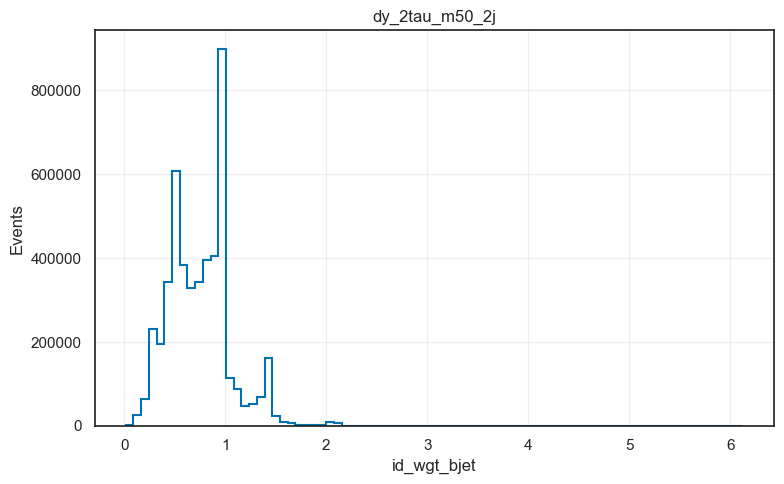


gluglu_h_2b (23/23 ROOT files with id_wgt_bjet, 11923 events)
  min=0.0685546, q05=0.434118, median=1, mean=0.898065, std=0.265849, q95=1.34259, max=4.17953


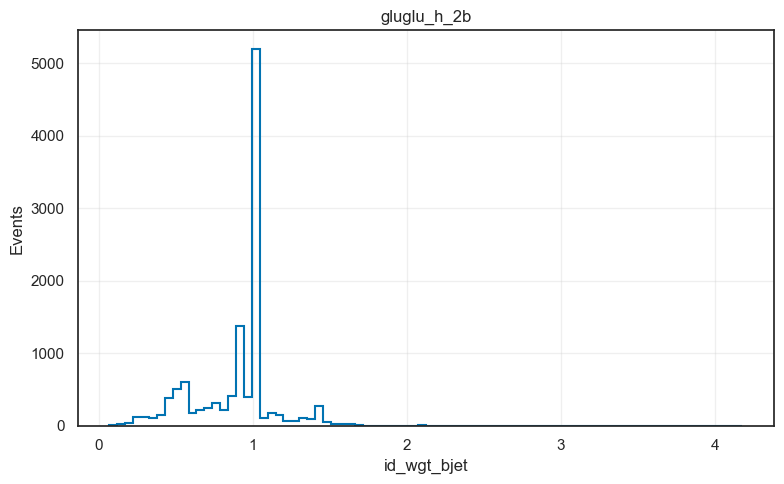


gluglu_h_2tau (5/5 ROOT files with id_wgt_bjet, 81369 events)
  min=0.046294, q05=0.47835, median=1, mean=0.903999, std=0.234822, q95=1.12187, max=4.47653


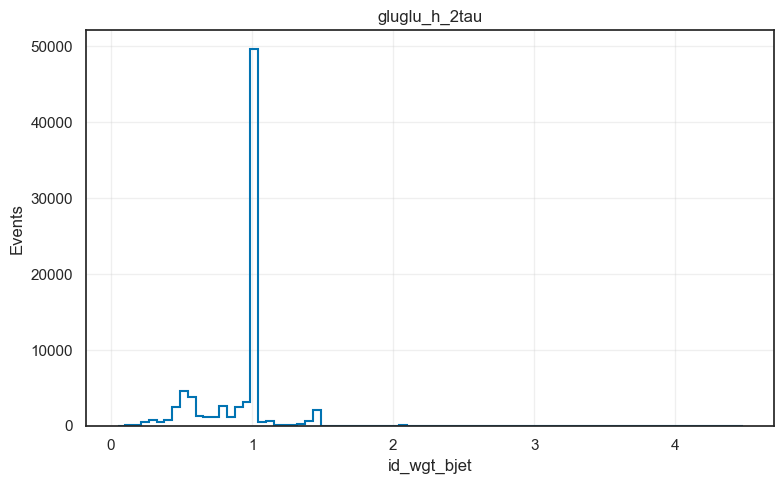

Skipping root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/Muon0_Run2024C-MINIv6NANOv15-v1/mt/Muon0_Run2024C-MINIv6NANOv15-v1_0.root: string ROOT::RDF::RInterfaceBase::GetColumnType(string_view column) =>
    runtime_error: Column "id_wgt_bjet" is not in a dataset and is not a custom column been defined.
Skipping root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/Muon0_Run2024C-MINIv6NANOv15-v1/mt/Muon0_Run2024C-MINIv6NANOv15-v1_1.root: string ROOT::RDF::RInterfaceBase::GetColumnType(string_view column) =>
    runtime_error: Column "id_wgt_bjet" is not in a dataset and is not a custom column been defined.
Skipping root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/Muon0_Run2024C-MINIv6NANOv15-v1/mt/Muon0_Run2024C-MINIv6NANOv15-v1_10.root: string ROOT::RDF::RInterfaceBase::GetColumnType(string_view column) =>
    runtime

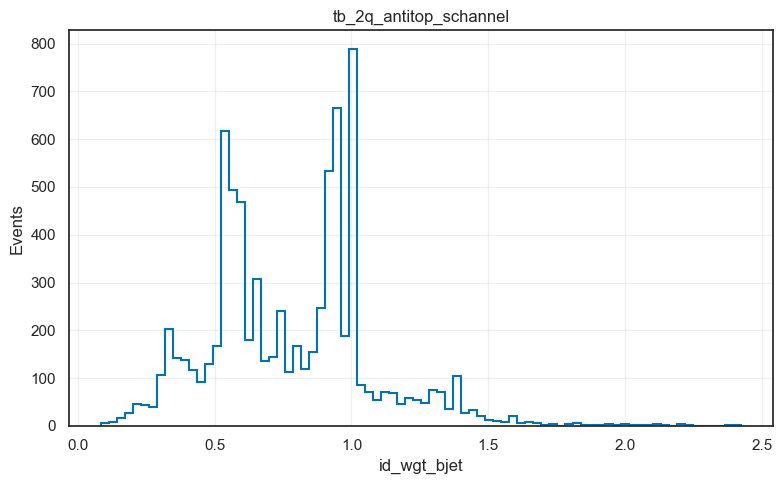

  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TBbarto2Q-s-channel_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TBbarto2Q-s-channel_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_0.root: 1/1508 (0.07%) non-finite values filtered
  ⚠️  Total: 1/8861 (0.01%) non-finite weights

tb_2q_top_schannel (9/9 ROOT files with id_wgt_bjet, 8860 events)
  min=0.0828338, q05=0.325933, median=0.804749, mean=0.794165, std=0.311277, q95=1.35705, max=3.41826


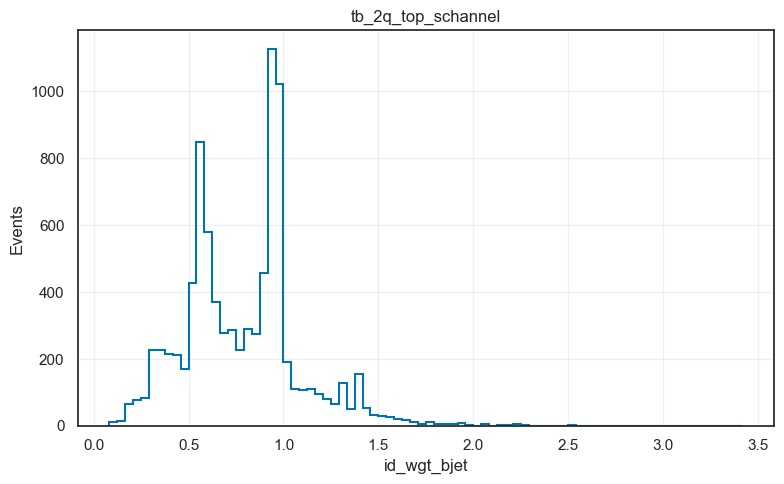

  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TbarBtoLNu-s-channel_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TbarBtoLNu-s-channel_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_1.root: 2/19917 (0.01%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TbarBtoLNu-s-channel_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TbarBtoLNu-s-channel_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_10.root: 1/7040 (0.01%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TbarBtoLNu-s-channel_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TbarBtoLNu-s-channel_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_11.root: 1/9706 (0.01%) non-finite values filt

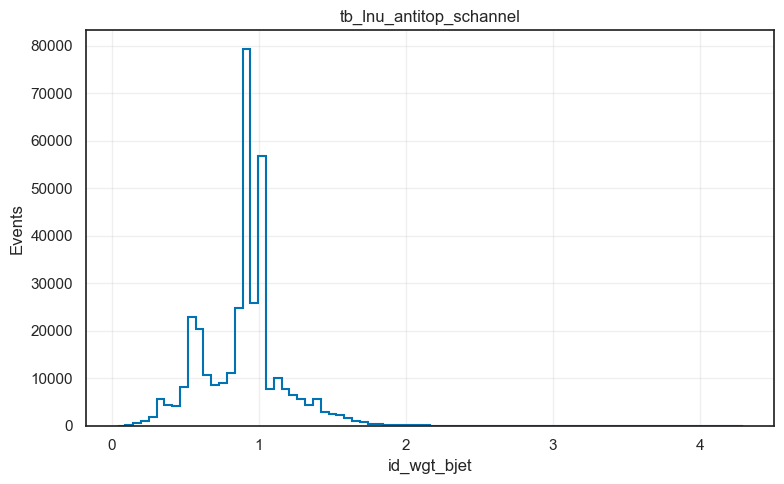

  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TBbartoLNu-s-channel_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TBbartoLNu-s-channel_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_0.root: 1/18388 (0.01%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TBbartoLNu-s-channel_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TBbartoLNu-s-channel_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_1.root: 2/17935 (0.01%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TBbartoLNu-s-channel_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TBbartoLNu-s-channel_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_10.root: 3/23801 (0.01%) non-finite values fil

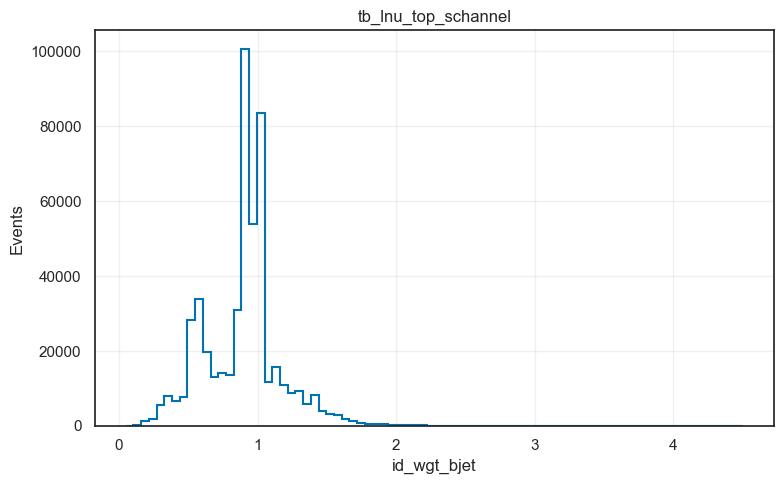

  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TbarBQto2Q-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TbarBQto2Q-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X_14.root: 1/471 (0.21%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TbarBQto2Q-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TbarBQto2Q-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X_18.root: 2/1332 (0.15%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TbarBQto2Q-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TbarBQto2Q-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII202

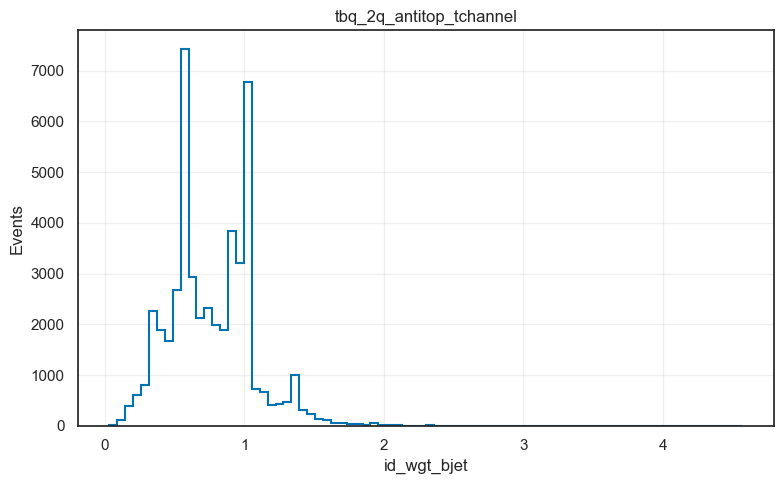

  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TBbarQto2Q-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TBbarQto2Q-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X_25.root: 1/2162 (0.05%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TBbarQto2Q-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TBbarQto2Q-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X_27.root: 1/2087 (0.05%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TBbarQto2Q-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TBbarQto2Q-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII20

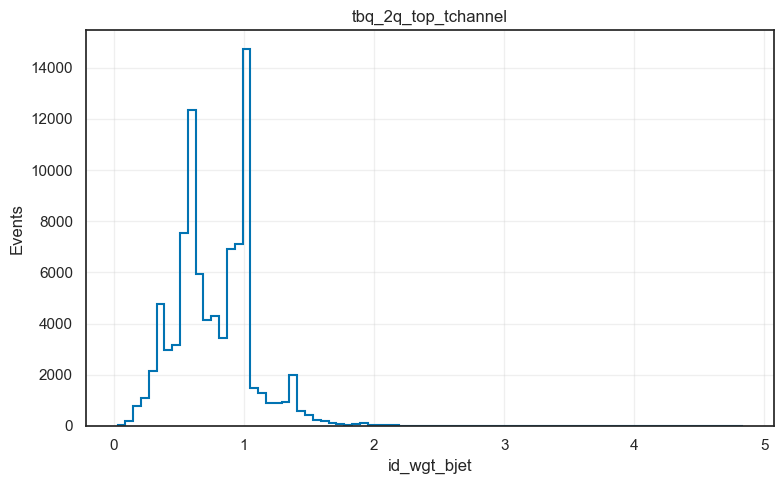

  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TbarBQtoLNu-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TbarBQtoLNu-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X_10.root: 2/21316 (0.01%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TbarBQtoLNu-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TbarBQtoLNu-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X_12.root: 1/23607 (0.00%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TbarBQtoLNu-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TbarBQtoLNu-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_

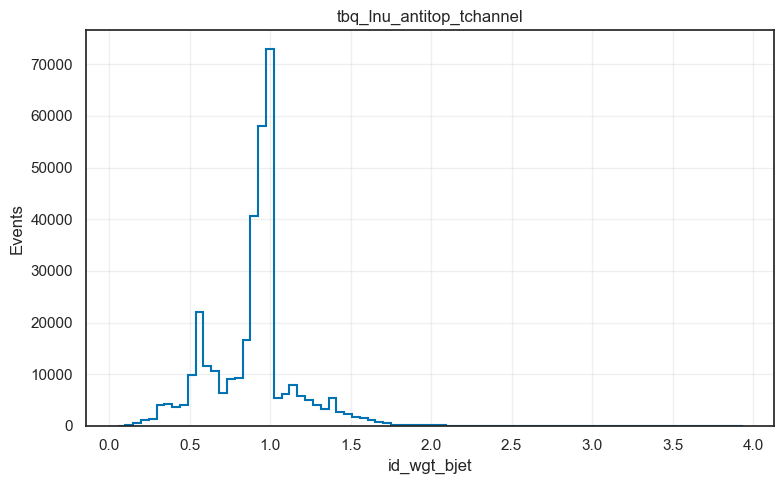

  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TBbarQtoLNu-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TBbarQtoLNu-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X_1.root: 1/16266 (0.01%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TBbarQtoLNu-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TBbarQtoLNu-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X_10.root: 3/18894 (0.02%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TBbarQtoLNu-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TBbarQtoLNu-t-channel-4FS_TuneCP5_13p6TeV_powheg-madspin-pythia8_R

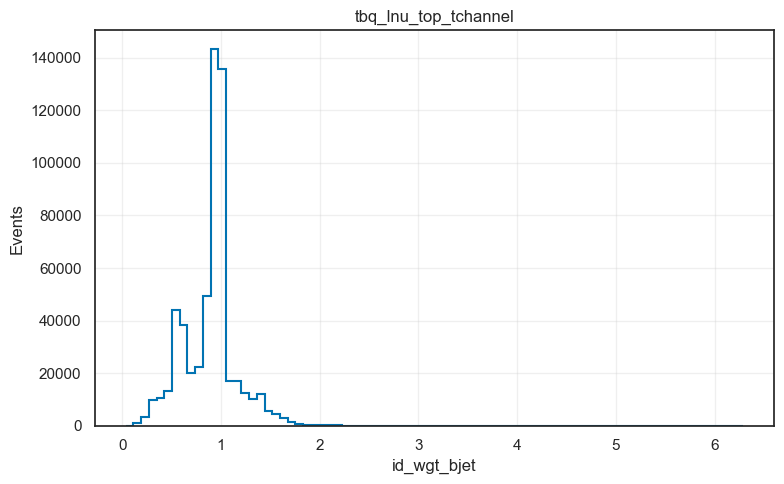


tt_2l2nu (78/78 ROOT files with id_wgt_bjet, 31461809 events)
  min=0.0188489, q05=0.400711, median=0.881183, mean=0.893548, std=0.336631, q95=1.48243, max=7.60334


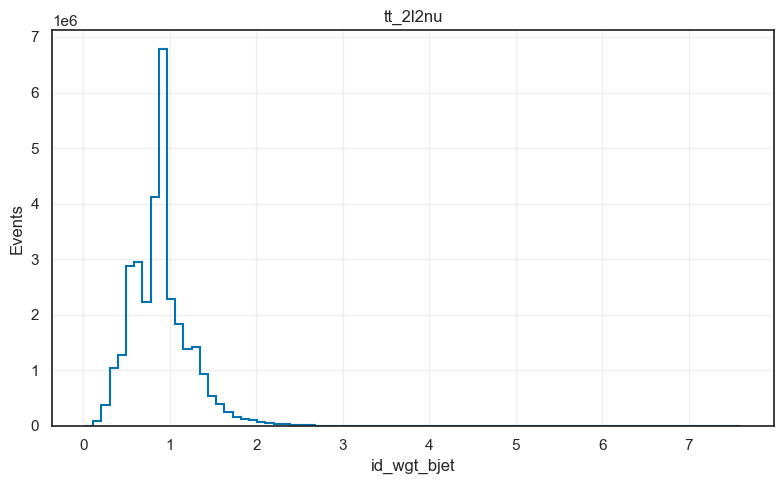


tt_4q (78/78 ROOT files with id_wgt_bjet, 966534 events)
  min=0.0252766, q05=0.241774, median=0.592879, mean=0.647382, std=0.318054, q95=1.25052, max=5.79141


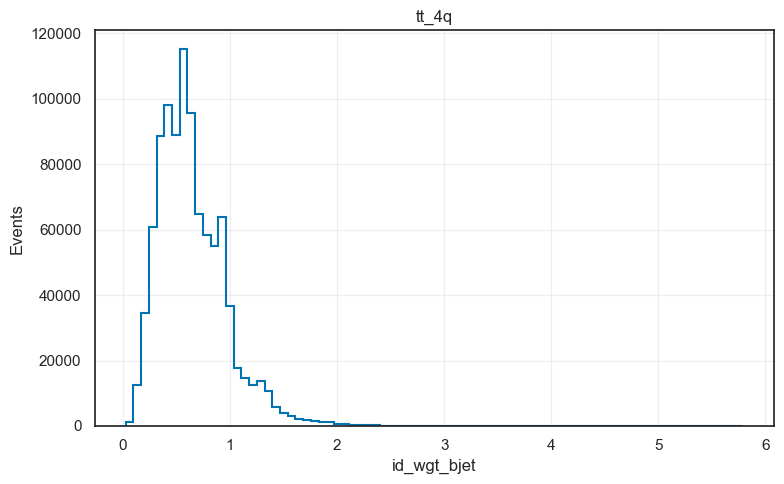


tt_lnu2q (79/79 ROOT files with id_wgt_bjet, 16930849 events)
  min=0.0204179, q05=0.322522, median=0.720129, mean=0.758744, std=0.32485, q95=1.34502, max=9.10696


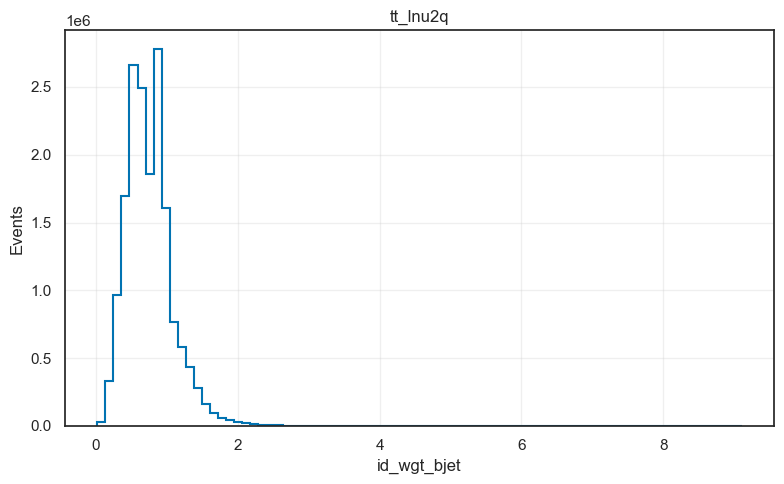


tth_h_2b (3/3 ROOT files with id_wgt_bjet, 64994 events)
  min=0.0273528, q05=0.253871, median=0.749604, mean=0.778992, std=0.387907, q95=1.46918, max=6.70719


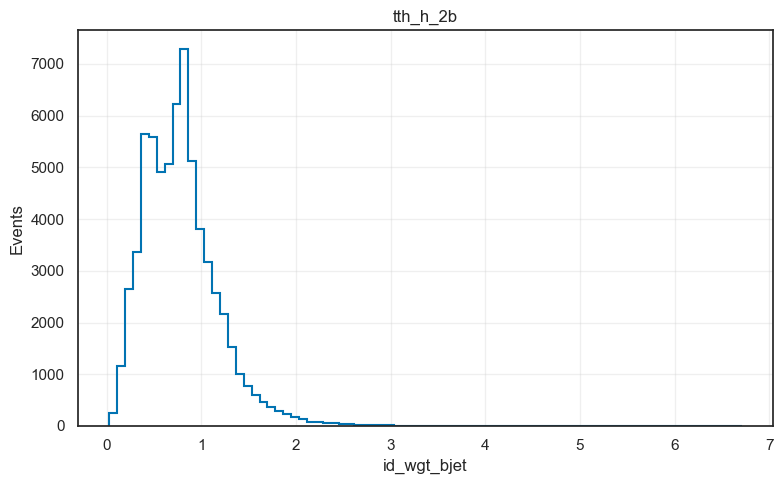


tth_h_non2b (54/54 ROOT files with id_wgt_bjet, 3440441 events)
  min=0.00572609, q05=0.206491, median=0.669104, mean=0.729703, std=0.414102, q95=1.46909, max=9.08881


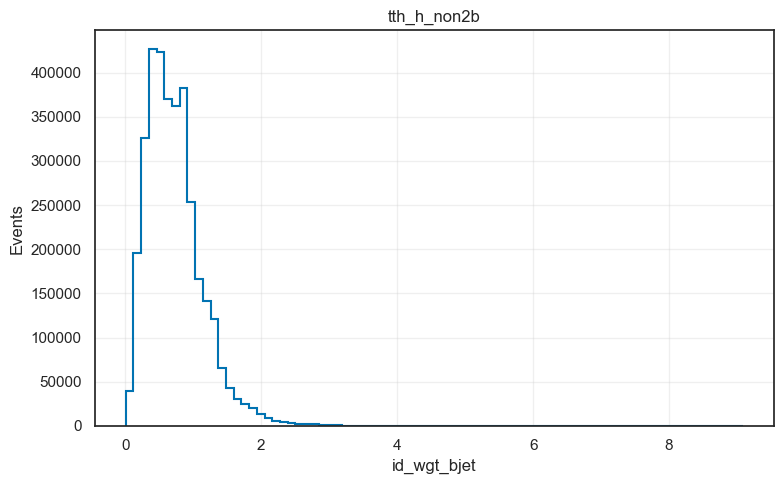

  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TWminusto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TWminusto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_0.root: 4/98817 (0.00%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TWminusto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TWminusto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_1.root: 3/72530 (0.00%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TWminusto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TWminusto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_10.root: 5/73149 (0.01%) non-finite values filtered
  root://cmsdcache-kit-disk.gr

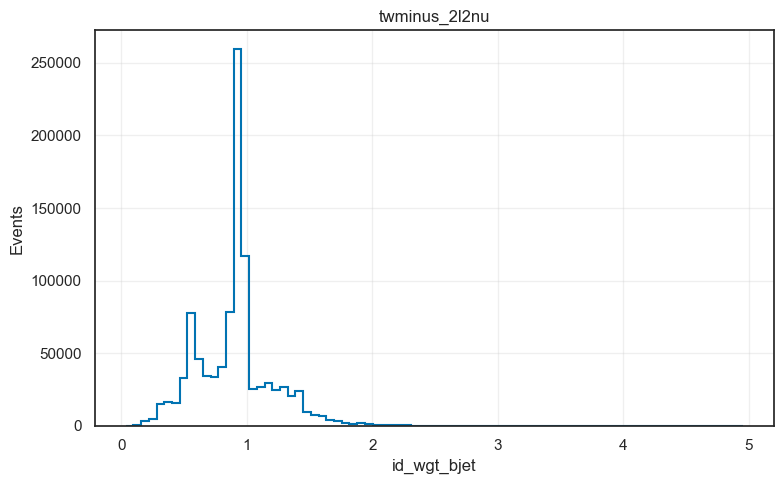

  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TWminustoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TWminustoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_0.root: 10/42990 (0.02%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TWminustoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TWminustoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_1.root: 13/43873 (0.03%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TWminustoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TWminustoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_10.root: 13/58398 (0.02%) non-finite values filtered
  root://cmsdcache-kit-disk

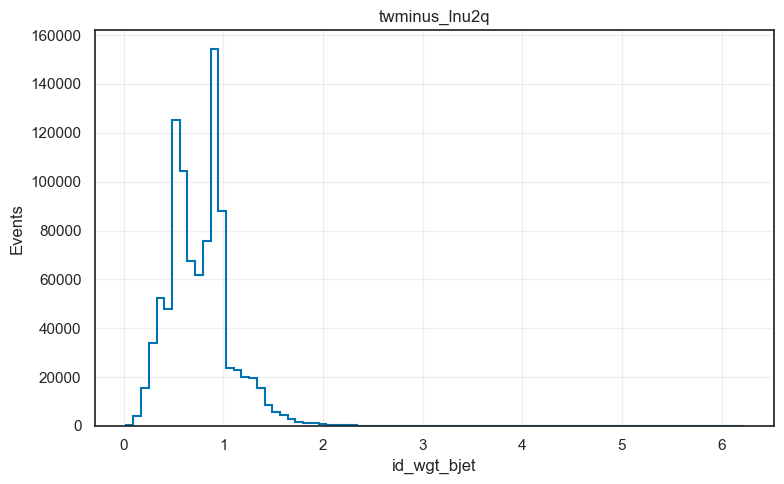

  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TbarWplusto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TbarWplusto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_0.root: 7/162334 (0.00%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TbarWplusto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TbarWplusto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_1.root: 12/152875 (0.01%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TbarWplusto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TbarWplusto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_2.root: 21/170012 (0.01%) non-finite values filtered
  root://cmsdc

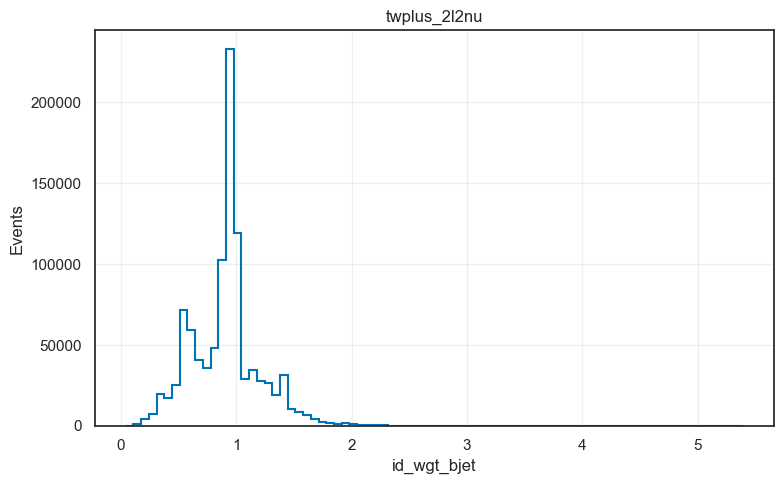

  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TbarWplustoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TbarWplustoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_0.root: 19/63175 (0.03%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TbarWplustoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TbarWplustoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_1.root: 17/73741 (0.02%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/TbarWplustoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/TbarWplustoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_RunIII2024Summer24NanoAODv15-150X_10.root: 13/36773 (0.04%) non-finite values filtered
  root://cmsdca

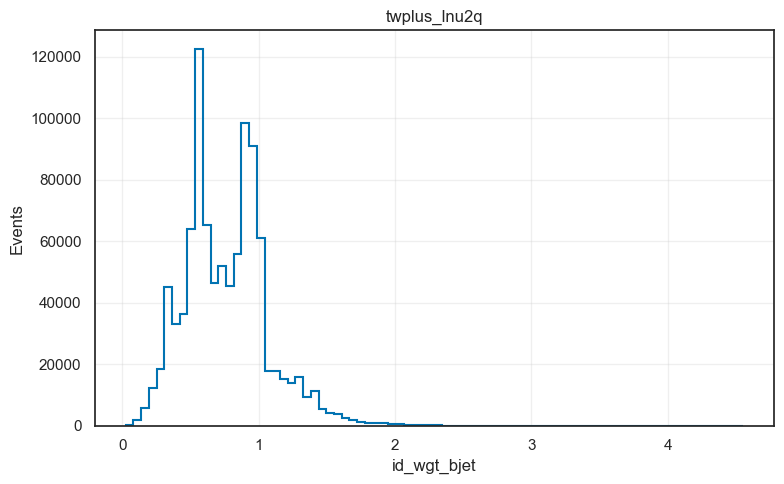


vbf_h_2b (21/21 ROOT files with id_wgt_bjet, 26399 events)
  min=0.0753598, q05=0.47835, median=0.93464, mean=0.911712, std=0.246265, q95=1.37424, max=3.31162


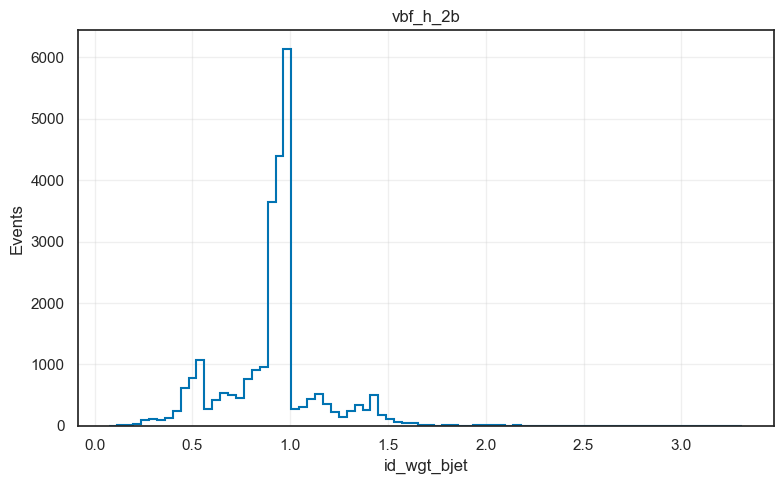


vbf_h_2tau (3/3 ROOT files with id_wgt_bjet, 80655 events)
  min=0.0532843, q05=0.47835, median=0.948078, mean=0.884004, std=0.238273, q95=1.32442, max=3.18062


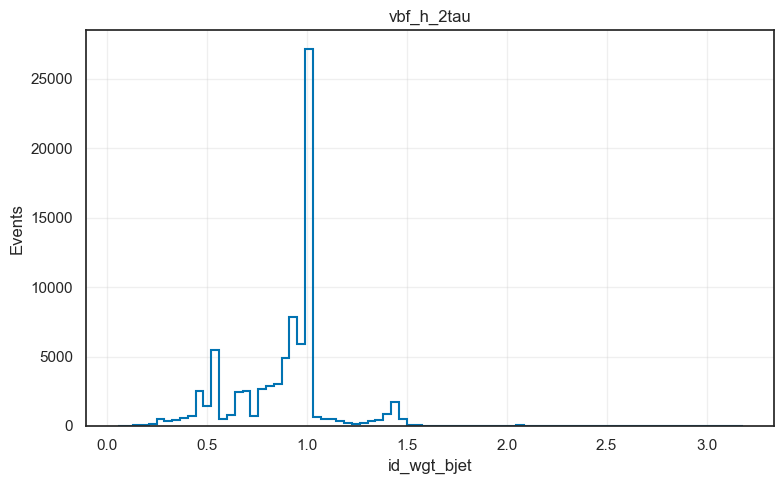

  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/WtoENu-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/WtoENu-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8_RunIII2024Summer24NanoAODv15-150X_111.root: 1/8 (12.50%) non-finite values filtered
  ⚠️  Total: 1/1961 (0.05%) non-finite weights

w_enu (300/302 ROOT files with id_wgt_bjet, 1960 events)
  min=0.278743, q05=0.589778, median=1, mean=0.975612, std=0.256236, q95=1.43158, max=2.18754


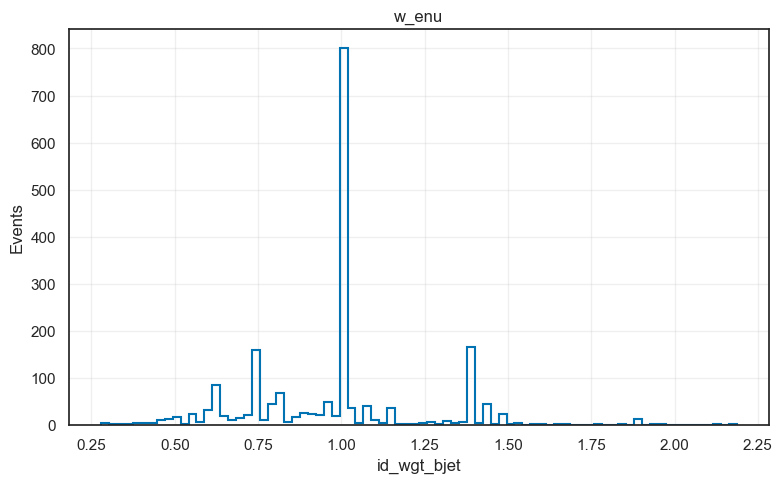

  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/WtoMuNu-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/WtoMuNu-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8_RunIII2024Summer24NanoAODv15-150X_0.root: 1/13766 (0.01%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/WtoMuNu-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/WtoMuNu-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8_RunIII2024Summer24NanoAODv15-150X_10.root: 1/17239 (0.01%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/WtoMuNu-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/WtoMuNu-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8_RunIII2024Summer24NanoAODv15-150X_100.root: 4/19667 (0.02%) non-finite values filtere

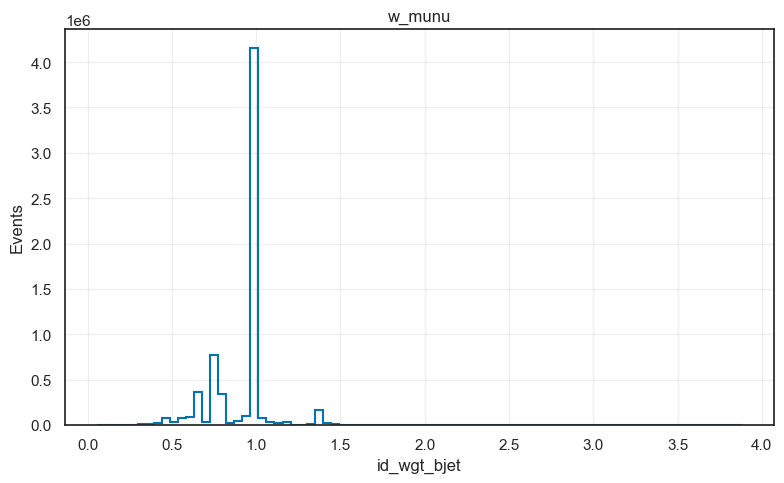

  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/WtoTauNu-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/WtoTauNu-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8_RunIII2024Summer24NanoAODv15-150X_100.root: 1/1203 (0.08%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/WtoTauNu-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/WtoTauNu-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8_RunIII2024Summer24NanoAODv15-150X_102.root: 1/1247 (0.08%) non-finite values filtered
  root://cmsdcache-kit-disk.gridka.de:1094//store/user/mmolch/CROWN/ntuples/ntuples-2026-05-07/CROWNRun/2024/WtoTauNu-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8_RunIII2024Summer24NanoAODv15-150X/mt/WtoTauNu-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8_RunIII2024Summer24NanoAODv15-150X_121.root: 1/1459 (0.07%) non-finite values f

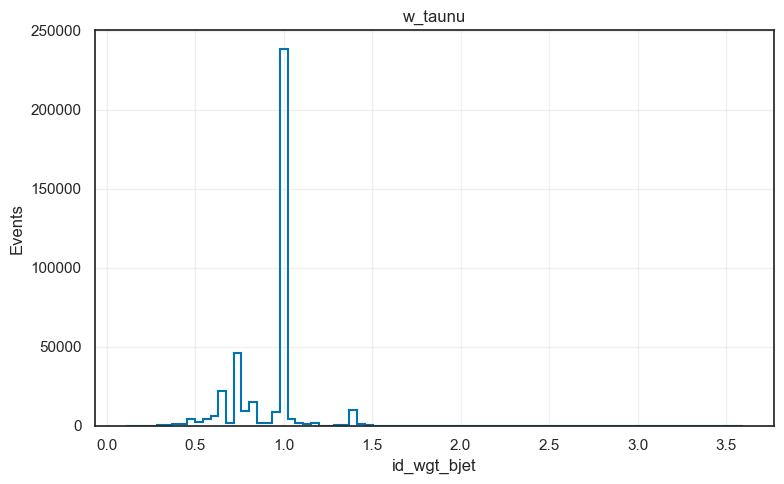


ww (29/29 ROOT files with id_wgt_bjet, 554680 events)
  min=0.0503084, q05=0.414635, median=0.992056, mean=0.848484, std=0.251457, q95=1.14681, max=3.88036


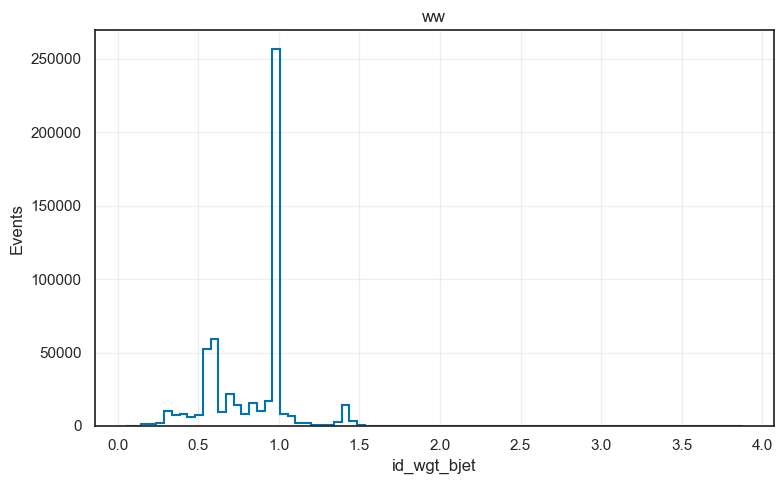


wz (31/31 ROOT files with id_wgt_bjet, 289970 events)
  min=0.0368807, q05=0.394263, median=0.938508, mean=0.874701, std=0.302678, q95=1.40832, max=3.21319


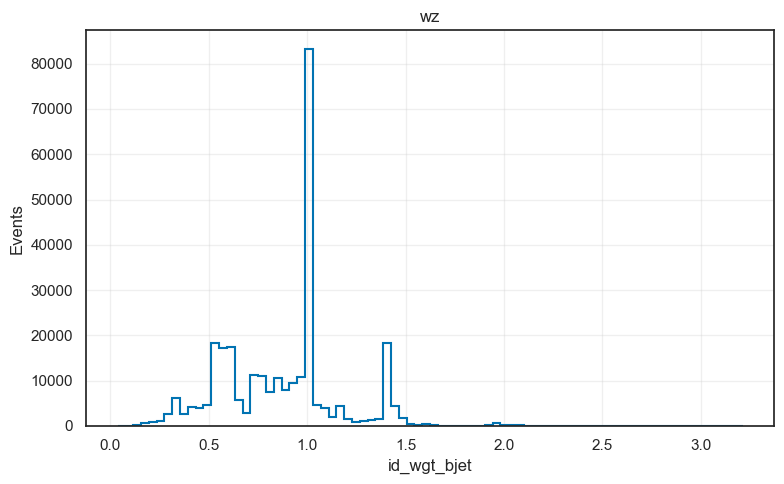


zz (8/8 ROOT files with id_wgt_bjet, 33660 events)
  min=0.0754849, q05=0.410236, median=0.956946, mean=0.929993, std=0.35043, q95=1.43924, max=3.25353


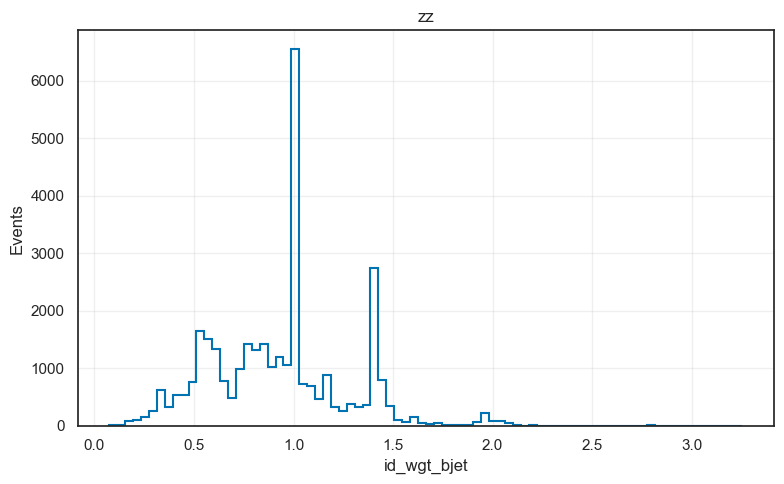

,events,min,q05,median,mean,std,q95,max,sample,yaml_file,root_files,usable_root_files,total_raw_weights,nonfinite_weights
0,152,0.290899,0.530766,1.000000,1.009913,0.271521,1.436101,2.934142,dy_2e_m10to50,2024_mt_dy_2e_m10to50.yaml,70,62,152,0
1,462,0.229213,0.530304,1.000000,1.002490,0.298933,1.442641,2.098588,dy_2e_m50_0j,2024_mt_dy_2e_m50_0j.yaml,55,55,462,0
2,4677,0.141443,0.548552,1.000000,1.110698,0.309089,1.483525,2.997899,dy_2e_m50_1j,2024_mt_dy_2e_m50_1j.yaml,211,211,4677,0
3,14813,0.055031,0.440445,1.000000,1.052085,0.430151,1.967814,5.864257,dy_2e_m50_2j,2024_mt_dy_2e_m50_2j.yaml,32,32,14813,0
4,215725,0.052728,0.500793,1.000000,0.953642,0.248914,1.431499,3.894888,dy_2mu_m10to50,2024_mt_dy_2mu_m10to50.yaml,102,102,215725,0
5,1174998,0.040607,0.570872,1.000000,1.087824,0.262507,1.443785,6.039089,dy_2mu_m50_0j,2024_mt_dy_2mu_m50_0j.yaml,54,54,1174998,0
6,17025275,0.023189,0.615751,1.000000,1.119662,0.269942,1.448650,7.303950,dy_2mu_m50_1j,2024_mt_dy_2mu_m50_1j.yaml,33,33,17025275,0
7,16613262,0.008066,0.424857,0.946682,0.948840,0.370257,1.448948,7.148676,dy_2mu_m50_2j,2024_mt_dy_2mu_m50_2j.yaml,167,167,16613262,0
8,9261,0.064669,0.460957,1.000000,0.886643,0.246740,1.212274,2.235719,dy_2tau_m10to50,2024_mt_dy_2tau_m10to50.yaml,72,72,9261,0
9,5084687,0.033618,0.817326,1.000000,0.982070,0.117374,1.000000,4.232913,dy_2tau_m50_0j,2024_mt_dy_2tau_m50_0j.yaml,267,267,5084687,0


In [5]:
summary_rows = []

for sample_name in sample_names:
    sample_info = sample_file_map[sample_name]
    root_files = sample_info['root_files']

    if not root_files:
        print(f"Skipping {sample_name}: no ROOT files listed in {sample_info['yaml_path'].name}")
        continue

    values, usable_files, finite_stats = load_weight_values(root_files)
    if values is None:
        print(f"\n{sample_name}: skipping because {WEIGHT_BRANCH} is not present in any ROOT file")
        continue

    summary = weight_summary(values)
    summary.update({
        "sample": sample_name,
        "yaml_file": os.path.basename(sample_info['yaml_path']),
        "root_files": len(root_files),
        "usable_root_files": len(usable_files),
        "total_raw_weights": finite_stats["total_raw"],
        "nonfinite_weights": finite_stats["total_nonfinite"],
    })
    summary_rows.append(summary)

    print(f"\n{sample_name} ({len(usable_files)}/{len(root_files)} ROOT files with {WEIGHT_BRANCH}, {summary['events']} events)")
    print(
        f"  min={summary['min']:.6g}, q05={summary['q05']:.6g}, median={summary['median']:.6g}, "
        f"mean={summary['mean']:.6g}, std={summary['std']:.6g}, q95={summary['q95']:.6g}, max={summary['max']:.6g}"
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    plot_weight_distribution(sample_name, values, ax=ax)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

summary_df = pd.DataFrame(summary_rows).sort_values("sample").reset_index(drop=True)
display(summary_df)
